
# Avance 4. Baseline

## Proyecto Integrador - MNA

### Equipo 21

Integrantes del equipo:
- Guadalupe Esmeralda González Maldonado - A01795767
- Marco Daniel Cameros Bobadilla - A01795655
- Jesús Armando Anaya Orozco - A01795464

Nombre del dataset: DDR2019

## Contexto y objetivo de este notebook

Este notebook presenta un baseline para clasificación de retinopatía diabética a partir de imágenes de fondo de ojo.

Un baseline es la primera solución razonable y reproducible. Sirve como punto de comparación para decidir si conviene seguir iterando sobre el problema con evidencia.

En esta entrega se usa como enfoque principal **ConvNeXt-Tiny** como backbone CNN y una **cabeza lineal** entrenada con pérdidas para desbalance (`Weighted CE` o `Focal`). Se busca una solución práctica, estable y fácil de interpretar en tiempo de cómputo razonable.

### Qué se busca demostrar con este baseline

- **Elección del modelo**: usamos transfer learning con un backbone preentrenado (`ConvNeXt-Tiny`) y una cabeza lineal entrenable.
- **Qué señales está usando**: analizamos magnitud de pesos de la cabeza lineal para identificar dimensiones dominantes del embedding.
- **Si generaliza o solo memoriza**: revisamos desempeño en validación y comportamiento por clase.
- **Cómo medimos desempeño**: priorizamos métricas robustas al desbalance (F1-macro / recall-macro), dejando accuracy como referencia secundaria.
- **Qué tan aceptable es el resultado**: comparamos contra baseline ingenuo (clase mayoritaria).


## 1) Setup del proyecto y dependencias

Esta sección define entorno, rutas y librerías para asegurar reproducibilidad. Es muy importante que la ejecución sea consistente entre corridas para comparar resultados de forma justa.


In [1]:
import os
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)

from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import ConvNeXt_Tiny_Weights
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode
from tqdm.auto import tqdm
import torch.nn.functional as F

#from sam_ml.datasets import DDR2019Dataset
#from sam_ml.preprocessing.filters import apply_clahe_bgr


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

def apply_clahe_bgr(img_bgr: np.ndarray) -> np.ndarray:
    """
    Apply CLAHE (Contrast-Limited Adaptive Histogram Equalization) to BGR image.

    Args:
        img_bgr: Input image in BGR format (numpy array)

    Returns:
        Processed image in BGR format
    """
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    return img_clahe


In [4]:
import os
from google.colab import drive
drive.mount('/content/drive')

DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto final"
os.chdir(DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
"""PyTorch dataset loader for the processed DDR2019 (Diabetic Retinopathy) dataset."""

from pathlib import Path
from typing import Literal, Optional

import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset
import cv2

try:
    from torchvision import transforms
except ImportError:
    transforms = None  # type: ignore[assignment]


def _stratified_split(
    df: pd.DataFrame,
    split: Literal["train", "val"],
    train_ratio: float,
    val_ratio: float,
    random_state: int,
) -> pd.DataFrame:
    """Split DataFrame by label so train/val preserve class proportions."""
    train_parts = []
    val_parts = []
    for _, group in df.groupby("label", group_keys=False):
        n = len(group)
        n_train = max(1, int(n * train_ratio)) if train_ratio > 0 else 0
        n_val = n - n_train
        if n_val == 0:
            n_train, n_val = n, 0
        shuffled = group.sample(frac=1, random_state=random_state)
        train_parts.append(shuffled.iloc[:n_train])
        if n_val > 0:
            val_parts.append(shuffled.iloc[n_train:])
    train_df = pd.concat(train_parts, ignore_index=True)
    val_df = pd.concat(val_parts, ignore_index=True) if val_parts else pd.DataFrame()
    return train_df if split == "train" else val_df


def _default_transform():
    """Default transform: PIL RGB to tensor (C, H, W), scale [0, 1]."""
    if transforms is None:
        raise ImportError("torchvision is required for default transform")
    return transforms.Compose([
        transforms.ToTensor(),
    ])


class DDR2019Dataset(Dataset):
    """PyTorch Dataset for the processed DDR2019 dataset.

    Expects the processed layout:
        data_dir/
            labels.csv   # columns: filename, label
            images/      # <filename>.jpg (e.g. 512x512 RGB)

    Supports train/val splits via stratified random splitting.
    """

    LABELS_CSV = "labels.csv"
    IMAGES_SUBDIR = "images"

    def __init__(
        self,
        data_dir: str | Path,
        split: Literal["train", "val", "all"] = "train",
        train_ratio: float = 0.8,
        val_ratio: float = 0.2,
        transform: Optional[object] = None,
        random_state: int = 42,
    ) -> None:
        """Initialize the DDR2019 dataset.

        Args:
            data_dir: Path to the processed DDR2019 directory (contains labels.csv and images/).
            split: "train", "val", or "all". "all" uses the full dataset.
            train_ratio: Fraction of data for train when split in ("train", "val"). Ignored if split=="all".
            val_ratio: Fraction of data for val when split in ("train", "val"). Ignored if split=="all".
            transform: Optional callable (e.g. torchvision.transforms). If None, uses ToTensor().
            random_state: Random seed for reproducible train/val split.
        """
        self.data_dir = Path(data_dir)
        self.split = split
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio
        self.random_state = random_state

        labels_path = self.data_dir / self.LABELS_CSV
        if not labels_path.exists():
            raise FileNotFoundError(f"Labels file not found: {labels_path}")

        self.images_dir = self.data_dir / self.IMAGES_SUBDIR
        if not self.images_dir.is_dir():
            raise FileNotFoundError(f"Images directory not found: {self.images_dir}")

        df = pd.read_csv(labels_path)
        if not {"filename", "label"}.issubset(df.columns):
            raise ValueError(
                f"labels.csv must have columns 'filename' and 'label'; got {list(df.columns)}"
            )
        df = df.astype({"filename": str, "label": int})

        if split == "all":
            self._rows = df.reset_index(drop=True)
        else:
            self._rows = _stratified_split(
                df, split, train_ratio, val_ratio, random_state
            )

        self.transform = transform if transform is not None else _default_transform()

    def __len__(self) -> int:
        return len(self._rows)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        row = self._rows.iloc[idx]
        filename = row["filename"]
        label = int(row["label"])

        image_path = self.images_dir / filename
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")

        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [6]:
# Resolver la raíz del proyecto de forma robusta.
_path = Path.cwd()
while _path != _path.parent and not (_path / "pyproject.toml").exists():
    _path = _path.parent
PROJECT_ROOT = _path if (_path / "pyproject.toml").exists() else Path.cwd()
os.chdir(PROJECT_ROOT)

# Fijar semillas para reproducibilidad.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset base para la baseline (baseline).
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "ddr2019"
LABELS_CSV = DATA_DIR / "labels.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR (baseline): {DATA_DIR}")
print(f"labels.csv existe: {LABELS_CSV.exists()}")


PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto final
DATA_DIR (baseline): /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto final/data/processed/ddr2019
labels.csv existe: True


In [7]:
# Cargar dataset base (una sola imagen por muestra) y validar contrato de salida.
base_dataset_train = DDR2019Dataset(
    data_dir=DATA_DIR,
    split="train",
    train_ratio=0.75,
    val_ratio=0.25,
    transform=transforms.ToTensor(),
    random_state=SEED,
)

base_dataset_all = DDR2019Dataset(
    data_dir=DATA_DIR,
    split="all",
    transform=transforms.ToTensor(),
    random_state=SEED,
)

image_sample, label_sample = base_dataset_train[0]

print(f"Muestras train: {len(base_dataset_train)}")
print(f"Muestras all: {len(base_dataset_all)}")
print(f"Shape imagen: {tuple(image_sample.shape)}")
print(f"Label de ejemplo: {label_sample}")


Muestras train: 9389
Muestras all: 12522
Shape imagen: (3, 512, 512)
Label de ejemplo: 0


## 2) Configuración de preprocesamiento para el baseline

Se usa la normalización esperada por el modelo preentrenado para reducir desajustes entre la distribución de entrada y los pesos aprendidos en ImageNet.

En términos simples, el "input size esperado" es el tamaño de imagen para el que la red fue entrenada originalmente. Mantener ese tamaño y esa normalización ayuda a sostener un comportamiento estable.


In [8]:

# Definir pesos de referencia para el baseline.
convnext_tiny_weights = ConvNeXt_Tiny_Weights.DEFAULT
convnext_tiny_preset = convnext_tiny_weights.transforms()

convnext_tiny_norm_mean = torch.tensor(convnext_tiny_preset.mean, dtype=torch.float32)
convnext_tiny_norm_std = torch.tensor(convnext_tiny_preset.std, dtype=torch.float32)

print("Normalización del baseline (ConvNeXt-Tiny):")
print(f"  input_size esperado: {convnext_tiny_preset.crop_size[0]} x {convnext_tiny_preset.crop_size[0]}")
print(f"  mean: {convnext_tiny_norm_mean.tolist()}")
print(f"  std: {convnext_tiny_norm_std.tolist()}")


Normalización del baseline (ConvNeXt-Tiny):
  input_size esperado: 224 x 224
  mean: [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
  std: [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]



## 3) Transformaciones de normalización del baseline

Se aplica normalización compatible con ConvNeXt-Tiny usando estadísticas de ImageNet.

Estas transformaciones preparan la imagen para que el backbone vea los datos en condiciones similares a su preentrenamiento.


In [9]:

def normalize_with_stats_torch(x: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    """Normalizar tensor RGB con media/desviación esperadas por un backbone."""
    m = mean.view(3, 1, 1).to(x.device, x.dtype)
    s = std.view(3, 1, 1).to(x.device, x.dtype).clamp_min(1e-8)
    return (x - m) / s


def denormalize_with_stats_torch(x: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    """Deshacer normalización RGB para visualización."""
    m = mean.view(3, 1, 1).to(x.device, x.dtype)
    s = std.view(3, 1, 1).to(x.device, x.dtype)
    return x * s + m


def preprocess_image_for_convnext_tiny(x: torch.Tensor) -> torch.Tensor:
    """Preprocesar imagen para baseline con ConvNeXt-Tiny."""
    x = x.float().clamp(0.0, 1.0)
    return normalize_with_stats_torch(x, convnext_tiny_norm_mean, convnext_tiny_norm_std)


## 4) Balanceo de clases

En retinopatía diabética existe desbalance de clases y esto impacta directamente la calidad del aprendizaje. Si se entrena sin control, el modelo tiende a optimizar para clases frecuentes y puede degradar el recall en clases con menos ejemplos.

### Decisión metodológica usada en este notebook

1. Primero se **fusionan 5 clases en 3** (`0`, `1+2`, `3+4`) para reducir ambigüedad entre severidades adyacentes.
2. Después se construye un **set de entrenamiento balanceado real** (el que entra al modelo), en lugar de reportar distribuciones parciales.
3. Se usa augmentación geométrica controlada (`original + hflip + vflip + 1 rotación`) y downsampling en mayoritarias cuando corresponde.

### Justificación de por qué se hace así

- **Evitar sesgo de frecuencia**: una clase con muchos más ejemplos domina la función objetivo.
- **Evitar sobre-augmentación sin criterio**: aumentar clases de manera desproporcionada puede volver a desbalancear el train.
- **Mantener factibilidad de cómputo**: se usa un objetivo alcanzable con los 4 modos de augmentación disponibles.

Conexión con rúbrica: este bloque justifica por qué **macro-F1** y **macro-recall** son métricas prioritarias. En escenarios desbalanceados, accuracy puede verse alta y aun así ocultar mal desempeño en clases menos frecuentes.

**Costo/beneficio**: balancear mejora cobertura por clase y estabilidad del entrenamiento, pero incrementa costo de cómputo por el número de muestras transformadas.

In [10]:
train_rows = base_dataset_train._rows.reset_index(drop=True).copy()

class_counts = train_rows["label"].value_counts().sort_index()
mean_count = class_counts.mean()
minority_threshold = mean_count * 0.5
minority_classes = set(class_counts[class_counts < minority_threshold].index.tolist())

AUGMENTATION_MULTIPLIER = 4
MAJORITY_CAP = 3500

augmentation_targets: dict[int, dict[str, float]] = {}
for label, count in class_counts.items():
    is_minority = int(label) in minority_classes
    target_count = int(count) * AUGMENTATION_MULTIPLIER if is_minority else int(count)
    augmentation_targets[int(label)] = {
        "current_count": int(count),
        "target_count": int(target_count),
        "multiplier": AUGMENTATION_MULTIPLIER if is_minority else 1,
        "is_minority": is_minority,
    }

downsampling_ratios: dict[int, dict[str, float]] = {}
for label, count in class_counts.items():
    is_majority = float(count) > float(mean_count)
    if is_majority and int(count) > MAJORITY_CAP:
        new_count = MAJORITY_CAP
        reduction_pct = (1.0 - (new_count / int(count))) * 100.0
    else:
        new_count = int(count)
        reduction_pct = 0.0
    downsampling_ratios[int(label)] = {
        "current_count": int(count),
        "new_count": int(new_count),
        "reduction_pct": float(reduction_pct),
        "is_downsampled": bool(is_majority and int(count) > MAJORITY_CAP),
    }

final_counts: dict[int, int] = {}
for label in sorted(class_counts.index.tolist()):
    if int(label) in minority_classes:
        final_counts[int(label)] = int(augmentation_targets[int(label)]["target_count"])
    else:
        final_counts[int(label)] = int(downsampling_ratios[int(label)]["new_count"])

original_imbalance_ratio = float(class_counts.max() / class_counts.min())
final_counts_series = pd.Series(final_counts).sort_index()
final_imbalance_ratio = float(final_counts_series.max() / final_counts_series.min())

print("Resumen de balanceo (baseline):")
print(f"  class_counts: {class_counts.to_dict()}")
print(f"  mean_count: {mean_count:.2f}")
print(f"  minority_threshold (50% mean): {minority_threshold:.2f}")
print(f"  minority_classes: {sorted(list(minority_classes))}")
print(f"  AUGMENTATION_MULTIPLIER: {AUGMENTATION_MULTIPLIER}")
print(f"  MAJORITY_CAP: {MAJORITY_CAP}")
print(f"  ratio original: {original_imbalance_ratio:.2f}:1")
print(f"  ratio final: {final_imbalance_ratio:.2f}:1")


Resumen de balanceo (baseline):
  class_counts: {0: 4699, 1: 472, 2: 3357, 3: 177, 4: 684}
  mean_count: 1877.80
  minority_threshold (50% mean): 938.90
  minority_classes: [1, 3, 4]
  AUGMENTATION_MULTIPLIER: 4
  MAJORITY_CAP: 3500
  ratio original: 26.55:1
  ratio final: 4.94:1


## 5) Utilidades de balanceo y augmentación

Estas utilidades concentran la lógica de muestreo por clase y de augmentación geométrica reproducible.

La idea es mantener reglas consistentes de balanceo para aumentar exposición de clases minoritarias y reducir dominancia de clases mayoritarias, sin alterar el flujo principal del baseline.


In [11]:
def _sample_indices_per_class(
    rows: pd.DataFrame,
    majority_cap: int,
    seed: int,
) -> list[int]:
    """Aplicar downsampling por clase para mayoritarias y mantener el resto."""
    rng = np.random.default_rng(seed)
    selected: list[int] = []

    counts = rows["label"].value_counts().sort_index()
    mean_count_local = counts.mean()

    for label in sorted(counts.index.tolist()):
        cls_rows = rows[rows["label"] == label]
        cls_indices = cls_rows.index.to_numpy()
        is_majority = counts[label] > mean_count_local

        if is_majority and len(cls_indices) > majority_cap:
            chosen = rng.choice(cls_indices, size=majority_cap, replace=False)
            selected.extend(chosen.tolist())
        else:
            selected.extend(cls_indices.tolist())

    return selected


def _build_augmented_sample_list(
    rows: pd.DataFrame,
    selected_indices: list[int],
    minority_set: set[int],
) -> list[tuple[int, int]]:
    """Construir lista (base_index, aug_id) según clase minoritaria/no minoritaria."""
    samples: list[tuple[int, int]] = []
    for idx in selected_indices:
        label = int(rows.loc[idx, "label"])
        if label in minority_set:
            # 0 = original, 1 = hflip, 2 = vflip, 3 = rot
            for aug_id in (0, 1, 2, 3):
                samples.append((int(idx), int(aug_id)))
        else:
            samples.append((int(idx), 0))
    return samples


def _draw_rotation_angles(rng: np.random.Generator) -> tuple[float, float]:
    """Generar dos ángulos distintos con magnitud en [10,15]."""

    def _one_angle() -> float:
        mag = float(rng.uniform(10.0, 15.0))
        sign = -1.0 if rng.random() < 0.5 else 1.0
        return sign * mag

    angle1 = _one_angle()
    angle2 = _one_angle()
    while abs(angle2 - angle1) < 1e-6:
        angle2 = _one_angle()
    return angle1, angle2



## 6) Verificación inicial del pipeline

Este bloque valida integridad básica del flujo antes de entrenar:

- formato y dimensiones esperadas de tensores,
- etiquetas en rango válido,
- consistencia entre tamaño del batch y contenido.

Esta verificación es muy importante para detectar errores tempranos de datos y evitar diagnósticos confusos durante el entrenamiento.


In [12]:
# Verificación rápida del dataset base (baseline).
batch_size = 8
baseline_loader = DataLoader(
    base_dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

images_batch, labels_batch = next(iter(baseline_loader))

print("Sanity check:")
print(f"  images_batch shape: {tuple(images_batch.shape)}")
print(f"  labels_batch shape: {tuple(labels_batch.shape)}")
print(f"  rango imágenes: [{float(images_batch.min()):.3f}, {float(images_batch.max()):.3f}]")


Sanity check:
  images_batch shape: (8, 3, 512, 512)
  labels_batch shape: (8,)
  rango imágenes: [0.000, 1.000]


=== Resumen de pipeline ===
DATA_DIR: /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto final/data/processed/ddr2019
Split train base: 9389
Split all base: 12522
images_batch shape: (8, 3, 512, 512)
labels_batch shape: (8,)
Distribución original (train): {0: 4699, 1: 472, 2: 3357, 3: 177, 4: 684}
Distribución final objetivo: {0: 3500, 1: 1888, 2: 3357, 3: 708, 4: 2736}
Ratio original: 26.55:1
Ratio final: 4.94:1


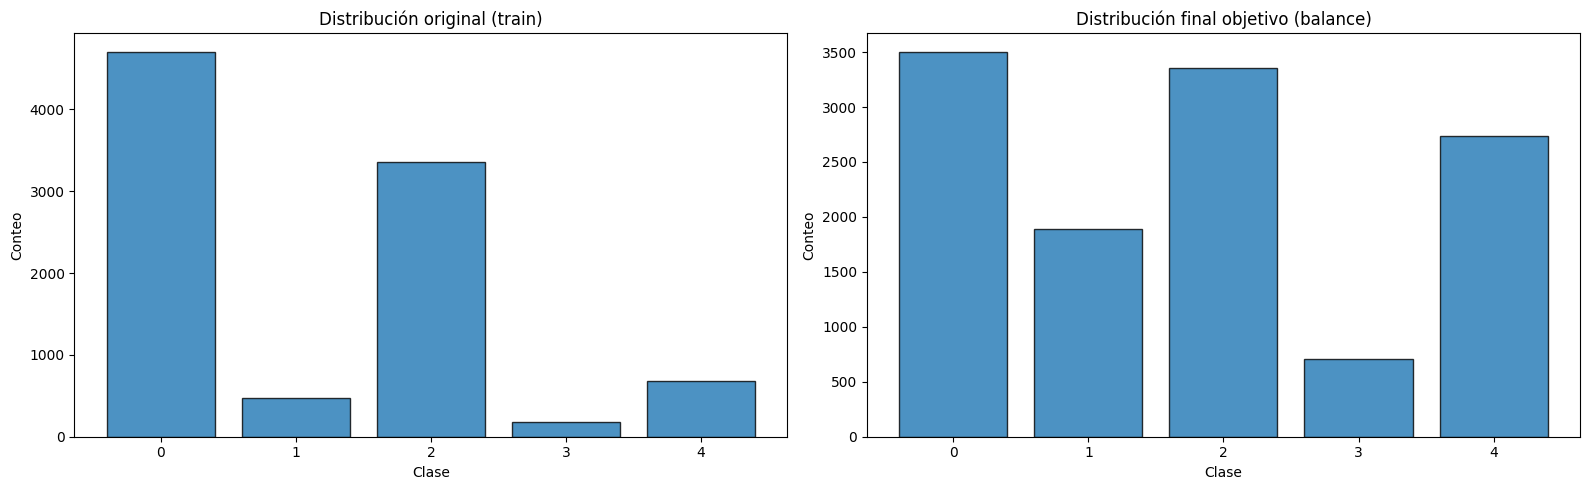

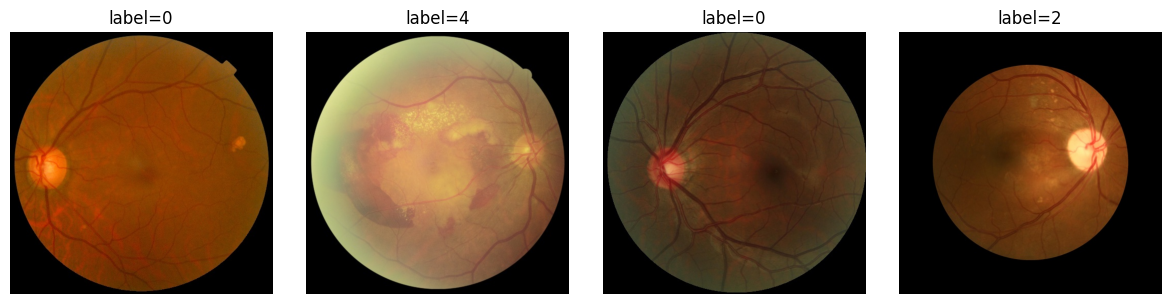

In [13]:
print("=== Resumen de pipeline ===")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Split train base: {len(base_dataset_train)}")
print(f"Split all base: {len(base_dataset_all)}")
print(f"images_batch shape: {tuple(images_batch.shape)}")
print(f"labels_batch shape: {tuple(labels_batch.shape)}")
print(f"Distribución original (train): {class_counts.to_dict()}")
print(f"Distribución final objetivo: {final_counts_series.to_dict()}")
print(f"Ratio original: {original_imbalance_ratio:.2f}:1")
print(f"Ratio final: {final_imbalance_ratio:.2f}:1")

# Graficar distribución original vs final objetivo.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

classes_sorted = sorted(class_counts.index.tolist())
x = np.arange(len(classes_sorted))
orig_values = [int(class_counts.loc[c]) for c in classes_sorted]
final_values = [int(final_counts_series.loc[c]) for c in classes_sorted]

axes[0].bar(x, orig_values, edgecolor="black", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes_sorted)
axes[0].set_title("Distribución original (train)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Conteo")

axes[1].bar(x, final_values, edgecolor="black", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes_sorted)
axes[1].set_title("Distribución final objetivo (balance)")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Conteo")

plt.tight_layout()
plt.show()

# Mostrar muestras del batch de la baseline.
n_show = min(4, images_batch.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = np.array([axes])

for i in range(n_show):
    image_vis = images_batch[i].detach().cpu().clamp(0.0, 1.0)
    axes[i].imshow(np.transpose(image_vis.numpy(), (1, 2, 0)))
    axes[i].set_title(f"label={int(labels_batch[i])}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Después de un primer intento con 5 clases, el flujo final del baseline se consolidó con fusión `5 -> 3` (`0`, `1+2`, `3+4`) y balanceo por época con `WeightedRandomSampler`. Con esta configuración sí se observó una mejora clara frente al predictor ingenuo y una validación estable.


## 7) Baseline (ConvNeXt-Tiny + Cabeza lineal con Weighted CE/Focal)

### ¿Por qué usamos este baseline?
Porque es una forma práctica de entrenar clasificación supervisada con costo controlado:

- **ConvNeXt-Tiny (preentrenado)** actúa como extractor de representación visual robusta.
- **Cabeza lineal** aprende el mapeo final a clases.
- **Pérdida Weighted CE/Focal** permite manejar mejor desbalance entre clases.
- En este run, la búsqueda seleccionó **`weighted_ce_eff`** (`effective_num`, `beta=0.999`).

### Desempeño mínimo esperado
El modelo debe superar el baseline ingenuo de predecir siempre la clase mayoritaria. En este run: baseline ingenuo `macro-F1=0.2223`; modelo individual `macro-F1=0.8709`; ensemble `macro-F1=0.8763`.


### Ajuste metodológico previo al feature engineering

Antes de extraer características se realizan ajustes deliberados al conjunto de datos para que el entrenamiento sea más estable, más fácil de interpretar y mejor alineado al riesgo clínico.

- Reducción de 5 a 3 clases: se agrupan etiquetas cercanas (`0, 1+2, 3+4`) para disminuir ambigüedad entre grados adyacentes y reducir ruido en las fronteras de decisión.
- Criterio clínico explícito: en este contexto conviene minimizar falsos negativos en casos de mayor severidad; por eso, cuando hay duda, se prefiere un sesgo conservador hacia categorías de mayor riesgo.
- Balanceo con objetivo verificable: se define un `target_count_per_class` realista y se valida con los conteos finales mostrados (`final_train_counts` y `final_train_proportions`).
- Augmentación controlada: se aplican transformaciones geométricas simples (`hflip`, `vflip`, `rotación`) para mejorar robustez sin modificar la semántica clínica de la imagen.
- CLAHE consistente en `train/val`: se aplica el mismo criterio de preprocesamiento en entrenamiento y validación para evitar cambios de distribución.

Muy importante: la distribución mostrada en esta sección corresponde al dataset final que entra al modelo, no a una etapa intermedia.

In [14]:
def _imagenet_stats_from_convnext_tiny() -> tuple[list[float], list[float]]:
    weights = ConvNeXt_Tiny_Weights.DEFAULT
    mean = list(weights.meta.get("mean", (0.485, 0.456, 0.406)))
    std = list(weights.meta.get("std", (0.229, 0.224, 0.225)))
    return mean, std


def seed_everything(seed: int) -> None:
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


def _to_gray(x: torch.Tensor) -> torch.Tensor:
    """Convertir RGB->grayscale (tensor CHW en [0,1])."""
    r, g, b = x[0], x[1], x[2]
    return (0.2989 * r + 0.5870 * g + 0.1140 * b).clamp(0.0, 1.0)


def _global_features(x: torch.Tensor, hist_bins: int = 16) -> torch.Tensor:
    """Features globales: mean/std por canal + histograma en escala de grises."""
    ch_mean = x.mean(dim=(1, 2))
    ch_std = x.std(dim=(1, 2), unbiased=False)

    gray = _to_gray(x)
    hist = torch.histc(gray, bins=int(hist_bins), min=0.0, max=1.0)
    hist = hist / (hist.sum().clamp_min(1.0))

    return torch.cat([ch_mean, ch_std, hist], dim=0).float()


def _apply_geometry(
    image: torch.Tensor,
    aug_id: int,
    idx: int,
    seed: int,
) -> torch.Tensor:
    """Augmentación más rica pero realista, reproducible por (seed, idx, aug_id)."""
    aug_id = int(aug_id)
    if aug_id == 0:
        return image

    rng = np.random.default_rng(int(seed) * 1_000_003 + int(idx) * 97 + aug_id * 9_973)
    x = image

    if aug_id == 1:
        x = TF.hflip(x)
    elif aug_id == 2:
        x = TF.vflip(x)
    elif aug_id == 3:
        angle = float(rng.uniform(-12.0, 12.0))
        x = TF.rotate(x, angle=angle, interpolation=InterpolationMode.BILINEAR, fill=0.0)
    elif aug_id == 4:
        h, w = int(x.shape[1]), int(x.shape[2])
        tx = int(rng.integers(-max(1, int(0.04 * w)), max(1, int(0.04 * w)) + 1))
        ty = int(rng.integers(-max(1, int(0.04 * h)), max(1, int(0.04 * h)) + 1))
        scale = float(rng.uniform(0.95, 1.05))
        shear_x = float(rng.uniform(-4.0, 4.0))
        shear_y = float(rng.uniform(-4.0, 4.0))
        angle = float(rng.uniform(-8.0, 8.0))
        x = TF.affine(
            x,
            angle=angle,
            translate=[tx, ty],
            scale=scale,
            shear=[shear_x, shear_y],
            interpolation=InterpolationMode.BILINEAR,
            fill=0.0,
        )
    elif aug_id == 5:
        b = float(rng.uniform(0.90, 1.10))
        c = float(rng.uniform(0.90, 1.10))
        s = float(rng.uniform(0.92, 1.08))
        h = float(rng.uniform(-0.02, 0.02))
        x = TF.adjust_brightness(x, b)
        x = TF.adjust_contrast(x, c)
        x = TF.adjust_saturation(x, s)
        x = TF.adjust_hue(x, h)
    elif aug_id == 6:
        sigma = float(rng.uniform(0.1, 1.0))
        x = TF.gaussian_blur(x, kernel_size=[3, 3], sigma=[sigma, sigma])
    elif aug_id == 7:
        x = TF.hflip(x)
        angle = float(rng.uniform(-6.0, 6.0))
        x = TF.rotate(x, angle=angle, interpolation=InterpolationMode.BILINEAR, fill=0.0)
        b = float(rng.uniform(0.95, 1.05))
        c = float(rng.uniform(0.95, 1.05))
        x = TF.adjust_brightness(x, b)
        x = TF.adjust_contrast(x, c)

    return x.clamp(0.0, 1.0)


def _apply_tta_batch(image: torch.Tensor, tta_id: int) -> torch.Tensor:
    """TTA determinista sobre batch normalizado (B,C,H,W)."""
    tta_id = int(tta_id)
    if tta_id == 0:
        return image
    if tta_id == 1:
        return torch.flip(image, dims=[3])  # hflip
    if tta_id == 2:
        return torch.flip(image, dims=[2])  # vflip
    if tta_id == 3:
        return torch.flip(image, dims=[2, 3])  # hvflip
    raise ValueError(f"TTA mode no soportado: {tta_id}")


LABEL_MAP_5_TO_3: dict[int, int] = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2}


class MappedLabelDataset(Dataset):
    """Wrap a base dataset and remap labels while preserving _rows support."""

    def __init__(self, base_dataset: DDR2019Dataset, label_map: dict[int, int]) -> None:
        self.base_dataset = base_dataset
        self.label_map = dict(label_map)
        self._rows = self.base_dataset._rows.copy()
        self._rows["label"] = self._rows["label"].map(self.label_map).astype(int)

    def __len__(self) -> int:
        return len(self.base_dataset)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        image, label = self.base_dataset[int(idx)]
        return image, int(self.label_map[int(label)])


class ClahePILTransform:
    """Apply CLAHE in BGR space and return a PIL RGB image."""

    def __call__(self, image: Image.Image) -> Image.Image:
        rgb = np.asarray(image.convert("RGB"), dtype=np.uint8)
        bgr = np.ascontiguousarray(rgb[..., ::-1])
        bgr_clahe = apply_clahe_bgr(bgr)
        rgb_clahe = np.ascontiguousarray(bgr_clahe[..., ::-1])
        return Image.fromarray(rgb_clahe)


class BaselineSingleFeatureDataset(Dataset):
    """Dataset baseline: ConvNeXt-Tiny + features globales extra."""

    def __init__(
        self,
        base_dataset: "DDR2019Dataset",
        samples: list[tuple[int, int]],
        seed: int,
        image_size: int = 224,
        hist_bins: int = 16,
        train_mode: bool = False,
        train_aug_modes: list[int] | None = None,
    ) -> None:
        self.base_dataset = base_dataset
        self.samples = list(samples)
        self.seed = int(seed)
        self.image_size = int(image_size)
        self.hist_bins = int(hist_bins)
        self.train_mode = bool(train_mode)
        self.train_aug_modes = [int(x) for x in (train_aug_modes if train_aug_modes is not None else [0])]
        self._rng = random.Random(self.seed)

        self.mean, self.std = _imagenet_stats_from_convnext_tiny()

    def __len__(self) -> int:
        return len(self.samples)

    def _prep_for_convnext_tiny(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x = TF.resize(
            x,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )
        x = x.float().clamp(0.0, 1.0)

        extra = _global_features(x, hist_bins=self.hist_bins)
        x_norm = TF.normalize(x, mean=self.mean, std=self.std)
        return x_norm, extra

    def __getitem__(self, item_idx: int) -> dict[str, torch.Tensor]:
        base_index, aug_id = self.samples[int(item_idx)]
        image, label = self.base_dataset[int(base_index)]
        image = image.float().clamp(0.0, 1.0)

        if self.train_mode:
            aug_id = int(aug_id)
            if aug_id < 0:
                aug_id = int(self._rng.choice(self.train_aug_modes))
            image_aug = _apply_geometry(
                image,
                aug_id=aug_id,
                idx=int(base_index),
                seed=self.seed,
            )
        else:
            image_aug = image

        image_in, extra = self._prep_for_convnext_tiny(image_aug)

        return {
            "image": image_in,
            "extra": extra,
            "label": torch.tensor(int(label), dtype=torch.long),
        }


class ConvNeXtTinyLinearHead(nn.Module):
    """ConvNeXt-Tiny con fine-tuning parcial del backbone + cabeza lineal."""

    def __init__(
        self,
        num_classes: int,
        extra_dim: int = 0,
        freeze_backbone: bool = True,
        unfreeze_backbone_blocks: int = 0,
        head_dropout: float = 0.30,
    ) -> None:
        super().__init__()
        backbone = models.convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        backbone.classifier[2] = nn.Identity()  # salida embedding (B, 768)
        self.backbone = backbone
        self.extra_dim = int(extra_dim)
        self.dropout = nn.Dropout(p=float(head_dropout))
        self.head = nn.Linear(768 + self.extra_dim, int(num_classes))

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

            if int(unfreeze_backbone_blocks) > 0:
                blocks = list(self.backbone.features.children())
                for block in blocks[-int(unfreeze_backbone_blocks):]:
                    for p in block.parameters():
                        p.requires_grad = True
        else:
            for p in self.backbone.parameters():
                p.requires_grad = True

    def forward(self, image: torch.Tensor, extra: torch.Tensor | None = None) -> torch.Tensor:
        emb = self.backbone(image)
        if self.extra_dim > 0 and extra is not None:
            x = torch.cat([emb, extra], dim=1)
        else:
            x = emb
        x = self.dropout(x)
        return self.head(x)


class FocalLoss(nn.Module):
    """Focal loss multicategoría sobre logits."""

    def __init__(
        self,
        gamma: float = 2.0,
        weight: torch.Tensor | None = None,
        reduction: str = "mean",
    ) -> None:
        super().__init__()
        self.gamma = float(gamma)
        self.weight = weight
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1.0 - pt) ** self.gamma) * ce

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray, float]:
    """Evalúa un modelo y devuelve labels, predicciones y pérdida media CE."""
    model.eval()
    y_true, y_pred = [], []
    loss_sum = 0.0
    n = 0

    for batch in loader:
        image = batch["image"].to(device, non_blocking=True)
        extra = batch["extra"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)

        logits = model(image, extra)
        loss = F.cross_entropy(logits, y)

        pred = torch.argmax(logits, dim=1)
        y_true.append(y.detach().cpu().numpy())
        y_pred.append(pred.detach().cpu().numpy())

        bs = int(y.shape[0])
        loss_sum += float(loss.item()) * bs
        n += bs

    y_true_np = np.concatenate(y_true, axis=0)
    y_pred_np = np.concatenate(y_pred, axis=0)
    avg_loss = loss_sum / max(1, n)
    return y_true_np, y_pred_np, avg_loss


@torch.no_grad()
def predict_proba(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    tta_modes: list[int] | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Predice probabilidades por muestra, con o sin TTA."""
    model.eval()
    modes = [0] if not tta_modes else [int(m) for m in tta_modes]

    y_true_all: list[np.ndarray] = []
    probs_all: list[np.ndarray] = []

    for batch in loader:
        image = batch["image"].to(device, non_blocking=True)
        extra = batch["extra"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)

        probs_accum = None
        for mode in modes:
            image_tta = _apply_tta_batch(image, mode)
            logits = model(image_tta, extra)
            probs = torch.softmax(logits, dim=1)
            probs_accum = probs if probs_accum is None else (probs_accum + probs)

        probs_accum = probs_accum / float(len(modes))
        y_true_all.append(y.detach().cpu().numpy())
        probs_all.append(probs_accum.detach().cpu().numpy())

    y_true_np = np.concatenate(y_true_all, axis=0)
    probs_np = np.concatenate(probs_all, axis=0)
    return y_true_np, probs_np


@torch.no_grad()
def ensemble_predict_proba(
    models_ens: list[nn.Module],
    loader: DataLoader,
    device: torch.device,
    tta_modes: list[int] | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Promedia probabilidades de múltiples seeds y TTA."""
    if len(models_ens) == 0:
        raise ValueError("El ensemble está vacío.")

    for m in models_ens:
        m.eval()

    modes = [0] if not tta_modes else [int(m) for m in tta_modes]

    y_true_all: list[np.ndarray] = []
    probs_all: list[np.ndarray] = []

    for batch in loader:
        image = batch["image"].to(device, non_blocking=True)
        extra = batch["extra"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)

        probs_accum = None
        n_votes = 0
        for model in models_ens:
            for mode in modes:
                image_tta = _apply_tta_batch(image, mode)
                logits = model(image_tta, extra)
                probs = torch.softmax(logits, dim=1)
                probs_accum = probs if probs_accum is None else (probs_accum + probs)
                n_votes += 1

        probs_accum = probs_accum / float(max(1, n_votes))
        y_true_all.append(y.detach().cpu().numpy())
        probs_all.append(probs_accum.detach().cpu().numpy())

    y_true_np = np.concatenate(y_true_all, axis=0)
    probs_np = np.concatenate(probs_all, axis=0)
    return y_true_np, probs_np


def cross_entropy_from_probs(y_true: np.ndarray, probs: np.ndarray) -> float:
    """Cross-entropy multicategoría a partir de probabilidades."""
    idx = np.arange(len(y_true))
    p = np.clip(probs[idx, y_true.astype(int)], 1e-12, 1.0)
    return float(-np.log(p).mean())


In [15]:
# 1) Cargar dataset simple con CLAHE consistente en todos los splits.
DATA_DIR_BASELINE = PROJECT_ROOT / "data" / "processed" / "ddr2019"

clahe_to_tensor = transforms.Compose([
    ClahePILTransform(),
    transforms.ToTensor(),
])

baseline_train_ds_raw = DDR2019Dataset(
    data_dir=DATA_DIR_BASELINE,
    split="train",
    train_ratio=0.75,
    val_ratio=0.25,
    transform=clahe_to_tensor,
    random_state=SEED,
)
baseline_val_ds_raw = DDR2019Dataset(
    data_dir=DATA_DIR_BASELINE,
    split="val",
    train_ratio=0.75,
    val_ratio=0.25,
    transform=clahe_to_tensor,
    random_state=SEED,
)

baseline_train_ds = MappedLabelDataset(baseline_train_ds_raw, LABEL_MAP_5_TO_3)
baseline_val_ds = MappedLabelDataset(baseline_val_ds_raw, LABEL_MAP_5_TO_3)

print("Dataset baseline - data decisions")
print(f"  DATA_DIR_BASELINE: {DATA_DIR_BASELINE}")
print(f"  train samples: {len(baseline_train_ds)}")
print(f"  val samples  : {len(baseline_val_ds)}")
print(f"  label mapping used (5->3): {LABEL_MAP_5_TO_3}")
print(f"  labels present in train after mapping: {sorted(baseline_train_ds._rows['label'].unique().tolist())}")
print("  preprocessing consistency: CLAHE is applied to both train and val")

Dataset baseline - data decisions
  DATA_DIR_BASELINE: /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto final/data/processed/ddr2019
  train samples: 9389
  val samples  : 3133
  label mapping used (5->3): {0: 0, 1: 1, 2: 1, 3: 2, 4: 2}
  labels present in train after mapping: [0, 1, 2]
  preprocessing consistency: CLAHE is applied to both train and val


In [16]:
# 2) Sampling + augmentation strategy for training (after 5->3 merge).
# Cambios implementados:
# - Sin duplicacion fija de filas en train.
# - WeightedRandomSampler para balancear por epoca.
# - Augmentacion estocastica sobre las muestras originales.
train_rows_baseline = baseline_train_ds._rows.reset_index(drop=True).copy()
class_counts_baseline = train_rows_baseline["label"].value_counts().sort_index()

IMAGE_SIZE = 320
BATCH_SIZE = 16
HIST_BINS = 16
AUGMENTATION_MODES = [0, 1, 2, 3, 4, 5, 6, 7]
SAMPLER_WEIGHT_EXPONENT = 0.5

majority_class_baseline = int(class_counts_baseline.idxmax())

train_samples = [(int(i), -1) for i in range(len(baseline_train_ds))]
train_eval_samples = [(int(i), 0) for i in range(len(baseline_train_ds))]
val_samples = [(int(i), 0) for i in range(len(baseline_val_ds))]

sampler_class_weights = (
    (class_counts_baseline.max() / class_counts_baseline.astype(np.float64)) ** SAMPLER_WEIGHT_EXPONENT
).sort_index()
sampler_weight_map = {int(k): float(v) for k, v in sampler_class_weights.items()}
train_sample_weights = train_rows_baseline["label"].map(sampler_weight_map).to_numpy(dtype=np.float64)

expected_sampler_mass = (
    pd.Series(train_sample_weights, index=train_rows_baseline.index)
    .groupby(train_rows_baseline["label"])
    .sum()
    .sort_index()
)
expected_sampler_proportions = expected_sampler_mass / expected_sampler_mass.sum()

train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(train_sample_weights, dtype=torch.double),
    num_samples=len(train_sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(SEED),
)

print("Training-set sampling summary (after merge, before model)")
print(f"  merged class_counts (raw train split): {class_counts_baseline.to_dict()}")
print(f"  majority_class: {majority_class_baseline}")
print(f"  image_size: {IMAGE_SIZE}")
print(f"  batch_size: {BATCH_SIZE}")
print(f"  augmentation_modes: {AUGMENTATION_MODES}")
print(f"  sampler_weight_exponent: {SAMPLER_WEIGHT_EXPONENT}")
print(f"  sampler_class_weights: {sampler_weight_map}")
print(
    "  expected sampler proportions (%): "
    + str({int(k): round(float(v) * 100.0, 2) for k, v in expected_sampler_proportions.items()})
)

train_fe_ds = BaselineSingleFeatureDataset(
    base_dataset=baseline_train_ds,
    samples=train_samples,
    seed=SEED,
    image_size=IMAGE_SIZE,
    hist_bins=HIST_BINS,
    train_mode=True,
    train_aug_modes=AUGMENTATION_MODES,
)
train_eval_ds = BaselineSingleFeatureDataset(
    base_dataset=baseline_train_ds,
    samples=train_eval_samples,
    seed=SEED,
    image_size=IMAGE_SIZE,
    hist_bins=HIST_BINS,
    train_mode=False,
)
val_fe_ds = BaselineSingleFeatureDataset(
    base_dataset=baseline_val_ds,
    samples=val_samples,
    seed=SEED,
    image_size=IMAGE_SIZE,
    hist_bins=HIST_BINS,
    train_mode=False,
)

num_workers = 0
train_loader = DataLoader(
    train_fe_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)
train_eval_loader = DataLoader(
    train_eval_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_fe_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)


Training-set sampling summary (after merge, before model)
  merged class_counts (raw train split): {0: 4699, 1: 3829, 2: 861}
  majority_class: 0
  image_size: 320
  batch_size: 16
  augmentation_modes: [0, 1, 2, 3, 4, 5, 6, 7]
  sampler_weight_exponent: 0.5
  sampler_class_weights: {0: 1.0, 1: 1.1077966291867398, 2: 2.3361522709826064}
  expected sampler proportions (%): {0: 42.9, 1: 38.73, 2: 18.37}


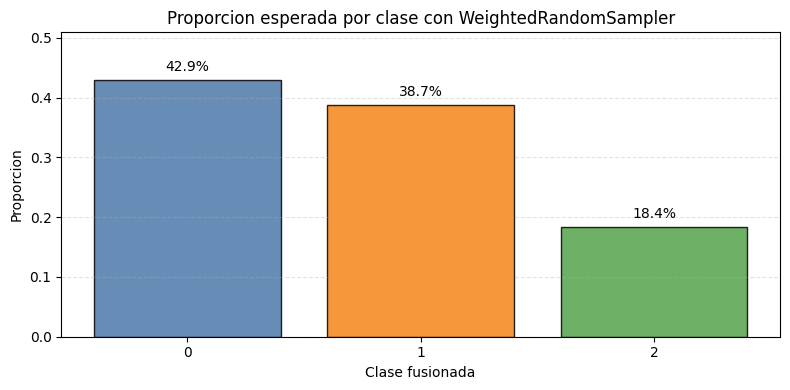

In [17]:
# Distribucion esperada del muestreo por clase
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    expected_sampler_proportions.index.astype(str),
    expected_sampler_proportions.values,
    color=["#4C78A8", "#F58518", "#54A24B"],
    edgecolor="black",
    alpha=0.85,
)

for bar, prop in zip(bars, expected_sampler_proportions.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{prop * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("Proporcion esperada por clase con WeightedRandomSampler")
ax.set_xlabel("Clase fusionada")
ax.set_ylabel("Proporcion")
ax.set_ylim(0, min(1.0, float(expected_sampler_proportions.max()) + 0.08))
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()


In [18]:

# 3) Configuracion de entrenamiento (ConvNeXt-Tiny + cabeza lineal).
TRAIN_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo para entrenamiento (baseline): {TRAIN_DEVICE}")

if TRAIN_DEVICE.type == "cuda":
    torch.set_float32_matmul_precision("high")

num_classes = int(len(sorted(baseline_train_ds._rows["label"].unique().tolist())))
extra_dim = int(train_fe_ds[0]["extra"].shape[0])

# Pesos de clase calculados sobre el split real de entrenamiento.
train_labels_for_weights = train_rows_baseline["label"].to_numpy(dtype=np.int64)
counts = np.bincount(train_labels_for_weights, minlength=num_classes).astype(np.float32)
class_weights = counts.sum() / (num_classes * np.maximum(counts, 1.0))
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=TRAIN_DEVICE)

print("Class counts (raw train split):", counts.astype(int).tolist())
print("Class weights:", class_weights.tolist())
print("Num classes:", num_classes)
print("Extra feature dim:", extra_dim)


Dispositivo para entrenamiento (baseline): cuda
Class counts (raw train split): [4699, 3829, 861]
Class weights: [0.6660282611846924, 0.8173587322235107, 3.634920597076416]
Num classes: 3
Extra feature dim: 22


### Desempeño mínimo esperado

Como referencia mínima, calculamos un predictor ingenuo que siempre predice la clase mayoritaria del entrenamiento.  
El baseline propuesto debe superar esta referencia para considerar que está aprendiendo señal útil. En este run, el predictor ingenuo obtuvo clase mayoritaria `0`, `macro-F1=0.2223` y `accuracy=0.5002`.

In [19]:
# Baseline ingenuo (clase mayoritaria=0) usando la distribucion real de train.
majority_class = majority_class_baseline
y_val_true = baseline_val_ds._rows["label"].to_numpy(dtype=int)

y_val_pred_naive = np.full(shape=len(y_val_true), fill_value=majority_class, dtype=int)

naive_f1_macro = f1_score(y_val_true, y_val_pred_naive, average="macro", zero_division=0)
naive_acc = accuracy_score(y_val_true, y_val_pred_naive)

print("Baseline ingenuo (clase mayoritaria)")
print(f"Clase mayoritaria: {majority_class}")
print(f"Validacion macro-F1: {naive_f1_macro:.4f}")
print(f"Validacion accuracy: {naive_acc:.4f}")


Baseline ingenuo (clase mayoritaria)
Clase mayoritaria: 0
Validacion macro-F1: 0.2223
Validacion accuracy: 0.5002


### Entrenamiento del clasificador (cabeza lineal + fine-tuning parcial)

En esta etapa entrenamos una **cabeza lineal** sobre embeddings de **ConvNeXt-Tiny** con **fine-tuning parcial** del backbone (ultimos bloques).

#### Estrategia de entrenamiento actualizada
- Se conserva el split original de entrenamiento.
- Se usa **`WeightedRandomSampler`** para balancear por epoca sin duplicar filas de forma permanente.
- La **augmentacion geometrica/fotometrica** se aplica de forma estocastica sobre las muestras originales.
- La evaluacion de entrenamiento se hace sobre un loader limpio, sin sampler ni augmentacion.

#### Funcion de perdida (ajuste sistematico)
Se prueban de forma sistematica varias opciones:
- **`weighted_ce`** con pesos por frecuencia inversa o por effective number.
- **`focal`** con `gamma` y pesos por clase.

Se selecciona automaticamente la configuracion con mejor **macro-F1 de validacion** antes de entrenar el ensemble final.

Resultado del ajuste sistematico en este run: mejor perdida `weighted_ce_eff` y mejor seed individual `42` con `val_macro-F1=0.8709`.


### Hiperparametros de entrenamiento

- **`IMAGE_SIZE`**: resolucion de entrada aumentada para conservar lesion pequena.
- **`BATCH_SIZE`**: reducido para compensar el mayor costo de memoria.
- **`LOSS_CANDIDATES`**: busqueda sistematica de perdida para desbalance.
- **`LOSS_SEARCH_EPOCHS`**: busqueda mas larga para elegir mejor perdida.
- **`FINAL_EPOCHS`**: epocas finales por seed en el ensemble.
- **`UNFREEZE_BACKBONE_BLOCKS`**: numero de bloques finales de ConvNeXt-Tiny a entrenar.
- **`HEAD_LR` / `BACKBONE_LR`**: LR diferencial para cabeza y backbone.
- **`SAMPLER_WEIGHT_EXPONENT`**: intensidad del rebalanceo del sampler.
- **`TTA_MODES`**: se deja en `0` mientras TTA no mejore macro-F1.
- **`ENSEMBLE_SEEDS`**: semillas usadas para el ensamble final.

Se selecciona el mejor checkpoint por **macro-F1 de validacion** en cada seed.


In [20]:
LOSS_SEARCH_EPOCHS = 8
FINAL_EPOCHS = 12

HEAD_LR = 5e-4
BACKBONE_LR = 3e-5
WEIGHT_DECAY = 5e-4
HEAD_DROPOUT = 0.40
LABEL_SMOOTHING = 0.05
EARLY_STOPPING_PATIENCE = 3

UNFREEZE_BACKBONE_BLOCKS = 3  # fine-tuning parcial mas profundo

# Inferencia sin TTA mientras macro-F1 no mejore con flips.
TTA_MODES = [0]

# Ensemble por semillas
ENSEMBLE_SEEDS = [SEED, SEED + 11, SEED + 29]

# Ajuste sistematico de perdida para desbalance
LOSS_CANDIDATES = [
    {"name": "weighted_ce_inv", "type": "weighted_ce", "weight_scheme": "inverse_freq"},
    {"name": "weighted_ce_eff", "type": "weighted_ce", "weight_scheme": "effective_num", "beta": 0.999},
    {"name": "focal_inv_g1.5", "type": "focal", "weight_scheme": "inverse_freq", "gamma": 1.5},
    {"name": "focal_eff_g2.0", "type": "focal", "weight_scheme": "effective_num", "beta": 0.999, "gamma": 2.0},
    {"name": "focal_eff_g2.5", "type": "focal", "weight_scheme": "effective_num", "beta": 0.999, "gamma": 2.5},
]


In [21]:
# Utilidades para modelo, pérdida y entrenamiento por seed

def compute_class_weights(
    labels: np.ndarray,
    num_classes: int,
    scheme: str = "inverse_freq",
    beta: float = 0.999,
) -> tuple[np.ndarray, np.ndarray]:
    counts = np.bincount(labels.astype(int), minlength=int(num_classes)).astype(np.float32)

    if scheme == "inverse_freq":
        weights = counts.sum() / (float(num_classes) * np.maximum(counts, 1.0))
    elif scheme == "effective_num":
        effective_num = 1.0 - np.power(float(beta), counts)
        weights = (1.0 - float(beta)) / np.maximum(effective_num, 1e-8)
        weights = weights / np.maximum(weights.mean(), 1e-8)
    else:
        raise ValueError(f"weight_scheme no soportado: {scheme}")

    return counts, weights.astype(np.float32)


def build_criterion(loss_cfg: dict, labels: np.ndarray, num_classes: int, device: torch.device) -> tuple[nn.Module, np.ndarray, np.ndarray]:
    scheme = str(loss_cfg.get("weight_scheme", "inverse_freq"))
    beta = float(loss_cfg.get("beta", 0.999))
    counts, class_w = compute_class_weights(labels, num_classes=num_classes, scheme=scheme, beta=beta)

    class_w_t = torch.tensor(class_w, dtype=torch.float32, device=device)

    loss_type = str(loss_cfg["type"])
    if loss_type == "weighted_ce":
        label_smoothing = float(loss_cfg.get("label_smoothing", LABEL_SMOOTHING))
        criterion = nn.CrossEntropyLoss(weight=class_w_t, label_smoothing=label_smoothing)
    elif loss_type == "focal":
        gamma = float(loss_cfg.get("gamma", 2.0))
        criterion = FocalLoss(gamma=gamma, weight=class_w_t)
    else:
        raise ValueError(f"LOSS_TYPE no soportado: {loss_type}")

    return criterion, counts, class_w


def build_model_and_optimizer(seed: int) -> tuple[nn.Module, torch.optim.Optimizer]:
    seed_everything(seed)

    model = ConvNeXtTinyLinearHead(
        num_classes=num_classes,
        extra_dim=extra_dim,
        freeze_backbone=True,
        unfreeze_backbone_blocks=UNFREEZE_BACKBONE_BLOCKS,
        head_dropout=HEAD_DROPOUT,
    ).to(TRAIN_DEVICE)

    head_params = [p for p in model.head.parameters() if p.requires_grad]
    backbone_params = [
        p for n, p in model.named_parameters()
        if p.requires_grad and not n.startswith("head.")
    ]

    param_groups = [{"params": head_params, "lr": HEAD_LR}]
    if len(backbone_params) > 0:
        param_groups.append({"params": backbone_params, "lr": BACKBONE_LR})

    optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    return model, optimizer


def train_one_run(seed: int, loss_cfg: dict, epochs: int) -> dict:
    model, optimizer = build_model_and_optimizer(seed)
    criterion, counts, class_w = build_criterion(
        loss_cfg=loss_cfg,
        labels=train_labels_for_weights,
        num_classes=num_classes,
        device=TRAIN_DEVICE,
    )

    best_state = None
    best_val_f1 = -1.0
    patience_counter = 0
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(1, int(epochs)),
        eta_min=1e-6,
    )
    history_local: list[dict[str, float | str | int]] = []

    for epoch in range(1, int(epochs) + 1):
        model.train()
        train_loss_sum = 0.0
        train_n = 0

        for batch in tqdm(train_loader, desc=f"Seed {seed} | {loss_cfg['name']} | Epoch {epoch}/{epochs}", leave=False):
            image = batch["image"].to(TRAIN_DEVICE, non_blocking=True)
            extra = batch["extra"].to(TRAIN_DEVICE, non_blocking=True)
            y = batch["label"].to(TRAIN_DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(image, extra)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            bs = int(y.shape[0])
            train_loss_sum += float(loss.item()) * bs
            train_n += bs

        train_loss = train_loss_sum / max(1, train_n)

        y_val_true, y_val_pred_epoch, val_ce = evaluate_model(model, val_loader, TRAIN_DEVICE)
        val_f1_epoch = float(f1_score(y_val_true, y_val_pred_epoch, average="macro", zero_division=0))

        history_local.append({
            "seed": int(seed),
            "loss_name": str(loss_cfg["name"]),
            "epoch": int(epoch),
            "train_loss": float(train_loss),
            "val_ce": float(val_ce),
            "val_f1_macro": float(val_f1_epoch),
        })

        if val_f1_epoch > (best_val_f1 + 1e-6):
            best_val_f1 = val_f1_epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        scheduler.step()
        head_lr_now = float(optimizer.param_groups[0]["lr"])
        print(
            f"Seed {seed} | {loss_cfg['name']} | Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | val_ce={val_ce:.4f} | val_f1_macro={val_f1_epoch:.4f} | head_lr={head_lr_now:.2e}"
        )

        if patience_counter >= int(EARLY_STOPPING_PATIENCE):
            print(
                f"Seed {seed} | {loss_cfg['name']} | early stopping en epoch {epoch:02d} "
                f"(patience={EARLY_STOPPING_PATIENCE})"
            )
            break

    if best_state is None:
        raise RuntimeError("No se guardó checkpoint durante entrenamiento.")

    model.load_state_dict(best_state)

    return {
        "seed": int(seed),
        "loss_cfg": dict(loss_cfg),
        "model": model,
        "best_val_f1": float(best_val_f1),
        "history": history_local,
        "class_counts": counts,
        "class_weights": class_w,
    }


print("Num classes:", num_classes)
print("Extra feature dim:", extra_dim)
print("Train labels for loss weighting:", Counter(train_labels_for_weights.tolist()))


Num classes: 3
Extra feature dim: 22
Train labels for loss weighting: Counter({0: 4699, 1: 3829, 2: 861})


In [22]:
# Entrenamiento: ajuste sistemático de pérdida + ensemble de seeds
from pathlib import Path
import json

search_seed = int(ENSEMBLE_SEEDS[0])

progress_dir = Path("checkpoints/loss_ensemble_progress")
progress_dir.mkdir(parents=True, exist_ok=True)
models_dir = progress_dir / "models"
models_dir.mkdir(parents=True, exist_ok=True)
status_path = progress_dir / "status.json"

def _load_status(path: Path) -> dict:
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    return {
        "loss_search_results": [],
        "best_loss_name": None,
        "ensemble_results": [],
    }

def _save_status(path: Path, payload: dict) -> None:
    tmp_path = path.with_suffix(".tmp")
    with tmp_path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=True, indent=2)
    tmp_path.replace(path)

status = _load_status(status_path)

loss_search_results: list[dict] = []
for row in status.get("loss_search_results", []):
    if str(row.get("loss_name", "")):
        loss_search_results.append({
            "loss_name": str(row["loss_name"]),
            "best_val_f1": float(row["best_val_f1"]),
            "class_weights": list(row["class_weights"]),
            "class_counts": list(row["class_counts"]),
        })

done_loss_names = {str(row["loss_name"]) for row in loss_search_results}

print(f"Buscando mejor pérdida con seed={search_seed} y {LOSS_SEARCH_EPOCHS} épocas por candidato...")
for cfg in LOSS_CANDIDATES:
    loss_name = str(cfg["name"])
    if loss_name in done_loss_names:
        print(f"Saltando candidato ya ejecutado: {loss_name}")
        continue

    run_cfg = train_one_run(seed=search_seed, loss_cfg=cfg, epochs=LOSS_SEARCH_EPOCHS)
    candidate_result = {
        "loss_name": loss_name,
        "best_val_f1": float(run_cfg["best_val_f1"]),
        "class_weights": run_cfg["class_weights"].tolist(),
        "class_counts": run_cfg["class_counts"].astype(int).tolist(),
    }
    loss_search_results.append(candidate_result)
    done_loss_names.add(loss_name)

    status["loss_search_results"] = loss_search_results
    _save_status(status_path, status)
    print(f"Progreso guardado en {status_path} tras {loss_name}")

if not loss_search_results:
    raise RuntimeError("No hay resultados de búsqueda de pérdida disponibles.")

loss_search_df = pd.DataFrame(loss_search_results).sort_values("best_val_f1", ascending=False).reset_index(drop=True)
best_loss_name = str(loss_search_df.iloc[0]["loss_name"])
best_loss_cfg = next(cfg for cfg in LOSS_CANDIDATES if cfg["name"] == best_loss_name)

status["best_loss_name"] = best_loss_name
_save_status(status_path, status)

print()
print("Resultados búsqueda de pérdida:")
display(loss_search_df)
print(f"Mejor configuración de pérdida: {best_loss_cfg}")

print()
print("Entrenando ensemble de seeds con la mejor pérdida...")
stored_ensemble = status.get("ensemble_results", [])
seed_to_result = {
    int(row["seed"]): row
    for row in stored_ensemble
    if str(row.get("loss_name")) == best_loss_name
}

ensemble_runs: list[dict] = []
ensemble_models: list[nn.Module] = []
all_history_records: list[dict] = []

for seed in ENSEMBLE_SEEDS:
    seed = int(seed)
    cached_row = seed_to_result.get(seed)

    if cached_row is not None and Path(cached_row["model_path"]).exists():
        print(f"Saltando seed ya ejecutada: {seed}")
        model = torch.load(cached_row["model_path"], map_location=DEVICE)
        ensemble_models.append(model)

        run = {
            "seed": seed,
            "loss_cfg": best_loss_cfg,
            "best_val_f1": float(cached_row["best_val_f1"]),
            "model": model,
            "history": [],
        }
        history_path = Path(cached_row.get("history_path", ""))
        if history_path.exists():
            run["history"] = pd.read_csv(history_path).to_dict("records")
        ensemble_runs.append(run)
        all_history_records.extend(run["history"])
        continue

    run = train_one_run(seed=seed, loss_cfg=best_loss_cfg, epochs=FINAL_EPOCHS)
    ensemble_runs.append(run)
    ensemble_models.append(run["model"])
    all_history_records.extend(run["history"])

    model_path = models_dir / f"seed_{seed}_{best_loss_name}.pt"
    history_path = models_dir / f"seed_{seed}_{best_loss_name}_history.csv"
    torch.save(run["model"], model_path)
    pd.DataFrame(run["history"]).to_csv(history_path, index=False)

    seed_to_result[seed] = {
        "seed": seed,
        "loss_name": best_loss_name,
        "best_val_f1": float(run["best_val_f1"]),
        "model_path": str(model_path),
        "history_path": str(history_path),
    }
    status["ensemble_results"] = list(seed_to_result.values())
    _save_status(status_path, status)
    print(f"Progreso guardado en {status_path} tras seed={seed}")

ensemble_summary_df = pd.DataFrame([
    {
        "seed": int(run["seed"]),
        "loss_name": str(run["loss_cfg"]["name"]),
        "best_val_f1": float(run["best_val_f1"]),
    }
    for run in ensemble_runs
]).sort_values("best_val_f1", ascending=False).reset_index(drop=True)

best_seed = int(ensemble_summary_df.iloc[0]["seed"])
best_seed_idx = int([int(run["seed"]) for run in ensemble_runs].index(best_seed))
final_model = ensemble_models[best_seed_idx]
best_val_f1 = float(ensemble_summary_df.iloc[0]["best_val_f1"])
history_df = pd.DataFrame(all_history_records)

print()
print("Resumen ensemble por seed:")
display(ensemble_summary_df)
print(f"Seed seleccionada para final_model (mejor individual): {best_seed}")
print(f"Estado guardado en: {status_path}")


Buscando mejor pérdida con seed=42 y 8 épocas por candidato...
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 357MB/s] 


Seed 42 | weighted_ce_inv | Epoch 1/8:   0%|          | 0/587 [00:00<?, ?it/s]

Seed 42 | weighted_ce_inv | Epoch 01 | train_loss=0.6194 | val_ce=0.5262 | val_f1_macro=0.7741 | head_lr=4.81e-04


Seed 42 | weighted_ce_inv | Epoch 2/8:   0%|          | 0/587 [00:00<?, ?it/s]

...

Seed 71 | weighted_ce_eff | Epoch 07 | train_loss=0.2882 | val_ce=0.3454 | val_f1_macro=0.8589 | head_lr=1.86e-04


Seed 71 | weighted_ce_eff | Epoch 8/12:   0%|          | 0/587 [00:00<?, ?it/s]

Seed 71 | weighted_ce_eff | Epoch 08 | train_loss=0.2706 | val_ce=0.3409 | val_f1_macro=0.8620 | head_lr=1.26e-04
Seed 71 | weighted_ce_eff | early stopping en epoch 08 (patience=3)
Progreso guardado en checkpoints/loss_ensemble_progress/status.json tras seed=71

Resumen ensemble por seed:


,seed,loss_name,best_val_f1
0,42,weighted_ce_eff,0.870930
1,53,weighted_ce_eff,0.870369
2,71,weighted_ce_eff,0.864931


Seed seleccionada para final_model (mejor individual): 42
Estado guardado en: checkpoints/loss_ensemble_progress/status.json


In [23]:
if len(ensemble_models) == 0:
    raise RuntimeError("No se entrenaron modelos para el ensemble.")

print("Mejor val macro-F1 (seed individual):", round(best_val_f1, 4))

print("Últimos registros de entrenamiento:")
display(history_df.tail())


Mejor val macro-F1 (seed individual): 0.8709
Últimos registros de entrenamiento:


,seed,loss_name,epoch,train_loss,val_ce,val_f1_macro
22,71,weighted_ce_eff,4,0.357135,0.353322,0.850857
23,71,weighted_ce_eff,5,0.334002,0.327039,0.864931
24,71,weighted_ce_eff,6,0.311852,0.340112,0.862132
25,71,weighted_ce_eff,7,0.288206,0.345366,0.858932
26,71,weighted_ce_eff,8,0.270627,0.340861,0.861951


### Evaluacion del modelo ajustado

La interpretacion se hace sobre este contexto:

- clases fusionadas en 3 niveles de severidad,
- muestreo balanceado por epoca con `WeightedRandomSampler`,
- augmentacion estocastica sin duplicacion fija de train,
- fine-tuning parcial mas profundo de ConvNeXt-Tiny,
- ajuste sistematico de la perdida para desbalance,
- inferencia sin TTA por defecto (`inference_modes=[0]`).

Se usa **macro-F1** como metrica principal y accuracy como complemento.

Resultados observados en validacion:
- modelo individual: `macro-F1=0.8709`, `CE=0.3286`, `accuracy=0.8841`;
- ensemble de seeds: `macro-F1=0.8763`, `CE=0.2909`.

La lectura de resultados se hace en este orden:
1. comparacion `single` vs `ensemble`,
2. desempeno por clase (`classification_report`),
3. patron de error (`confusion_matrix`).


In [24]:
# 5) Evaluacion en validacion sin TTA (inference_modes=[0]): modelo individual vs ensemble.
inference_modes = TTA_MODES if TTA_MODES else [0]

y_val_single, probs_val_single = predict_proba(final_model, val_loader, TRAIN_DEVICE, tta_modes=inference_modes)
y_val_ens, probs_val_ens = ensemble_predict_proba(ensemble_models, val_loader, TRAIN_DEVICE, tta_modes=inference_modes)

y_val_pred_single = np.argmax(probs_val_single, axis=1)
y_val_pred_ens = np.argmax(probs_val_ens, axis=1)

val_f1_single = f1_score(y_val_single, y_val_pred_single, average="macro", zero_division=0)
val_f1_ens = f1_score(y_val_ens, y_val_pred_ens, average="macro", zero_division=0)

val_ce_single = cross_entropy_from_probs(y_val_single, probs_val_single)
val_ce_ens = cross_entropy_from_probs(y_val_ens, probs_val_ens)

print("Validation macro-F1 (ConvNeXt-Tiny + linear head)")
print(f"Inference modes used: {inference_modes}")
print(f"Single model:         {val_f1_single:.4f} | CE={val_ce_single:.4f}")
print(f"Ensemble seeds:       {val_f1_ens:.4f} | CE={val_ce_ens:.4f}")

print()
print("Modelo final reportado (single model, inferencia actual) - classification report")
print(classification_report(y_val_single, y_val_pred_single, digits=4, zero_division=0))

y_val = y_val_single
y_pred = y_val_pred_single
val_ce = val_ce_single
val_f1_macro = val_f1_single


Validation macro-F1 (ConvNeXt-Tiny + linear head)
Inference modes used: [0]
Single model:         0.8709 | CE=0.3286
Ensemble seeds:       0.8763 | CE=0.2909

Modelo final reportado (single model, inferencia actual) - classification report
              precision    recall  f1-score   support

           0     0.9088    0.9221    0.9154      1567
           1     0.8747    0.8357    0.8547      1278
           2     0.7981    0.8924    0.8426       288

    accuracy                         0.8841      3133
   macro avg     0.8605    0.8834    0.8709      3133
weighted avg     0.8847    0.8841    0.8840      3133



### Senal de generalizacion

Ademas de validacion, se compara entrenamiento vs validacion usando:
- un `train_eval_loader` limpio, sin sampler y sin augmentacion,
- el mismo esquema de inferencia configurado arriba (sin TTA por defecto).

Esto evita sobreestimar el F1 de entrenamiento por medir sobre muestras reamostradas o aumentadas.

En este run, el modelo individual reporto `train macro-F1=0.9847`, `val macro-F1=0.8709`, con brecha `0.1138` y `train CE=0.0888`, lo que sugiere sobreajuste moderado pero controlado.


In [25]:
y_train, probs_train_single = predict_proba(
    final_model,
    train_eval_loader,
    TRAIN_DEVICE,
    tta_modes=TTA_MODES,
)
y_train_pred = np.argmax(probs_train_single, axis=1)
train_ce = cross_entropy_from_probs(y_train, probs_train_single)

train_f1_macro = f1_score(y_train, y_train_pred, average="macro", zero_division=0)
val_f1_macro = f1_score(y_val, y_pred, average="macro", zero_division=0)

print("Comparacion de generalizacion (single model, train limpio)")
print(f"Entrenamiento macro-F1: {train_f1_macro:.4f}")
print(f"Validacion   macro-F1: {val_f1_macro:.4f}")
print(f"Brecha (train - val): {(train_f1_macro - val_f1_macro):.4f}")
print(f"Train CE (referencia): {train_ce:.4f}")


Comparacion de generalizacion (single model, train limpio)
Entrenamiento macro-F1: 0.9847
Validacion   macro-F1: 0.8709
Brecha (train - val): 0.1138
Train CE (referencia): 0.0888


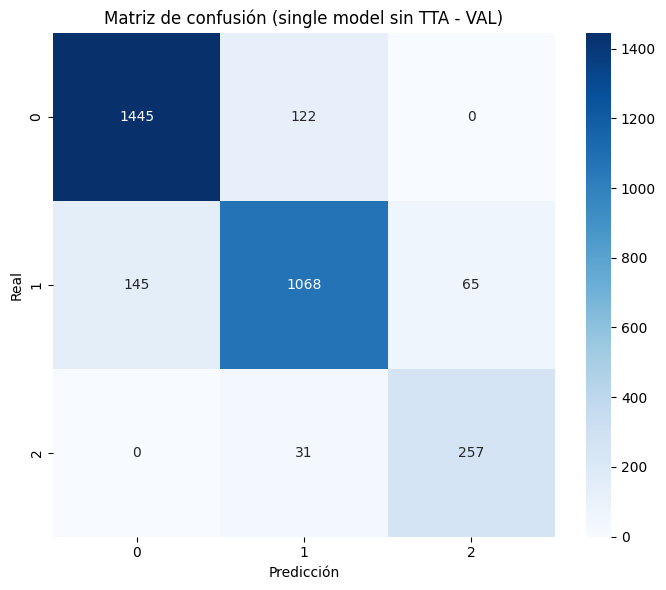

In [26]:
# 6) Confusion matrix (single model sin TTA on VAL).
labels_sorted = sorted(int(x) for x in np.unique(y_val))
cm = confusion_matrix(y_val, y_pred, labels=labels_sorted)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
)
plt.title("Matriz de confusión (single model sin TTA - VAL)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()



### Importancia de características

En este baseline, las características corresponden a las dimensiones del embedding generado por ConvNeXt-Tiny.  
La importancia se analiza con la magnitud absoluta de los pesos de la cabeza lineal (promedio entre clases).


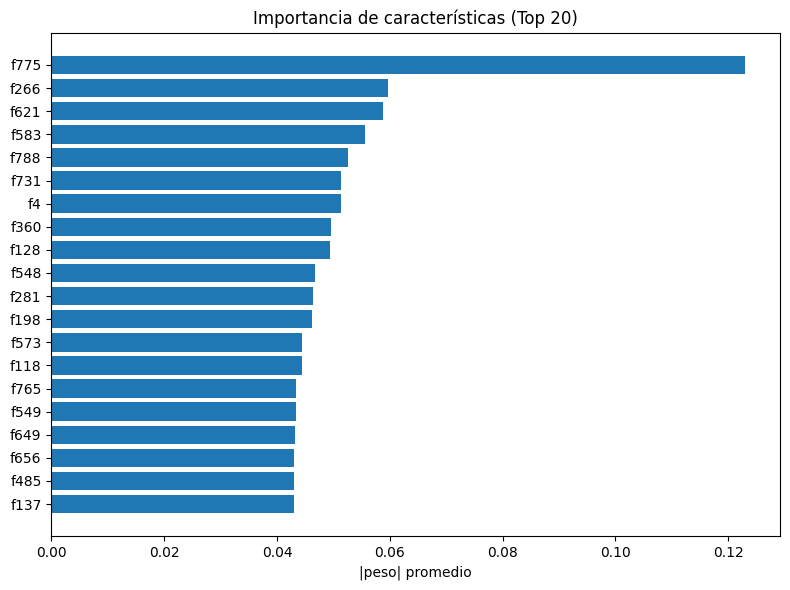

Top características por magnitud absoluta de pesos:


,feature,importance
0,f775,0.123010
1,f266,0.059676
2,f621,0.058751
3,f583,0.055624
4,f788,0.052575
5,f731,0.051424
6,f4,0.051368
7,f360,0.049521
8,f128,0.049418
9,f548,0.046686


In [27]:

# Importancia de características (cabeza lineal): magnitud absoluta de pesos
coef = final_model.head.weight.detach().cpu().numpy()  # (num_classes, embedding_dim + extra_dim)
importance = np.mean(np.abs(coef), axis=0)

importance_df = (
    pd.DataFrame({
        "feature": [f"f{i}" for i in range(len(importance))],
        "importance": importance,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_k = 20
top_df = importance_df.head(top_k)

plt.figure(figsize=(8, 6))
plt.barh(top_df["feature"][::-1], top_df["importance"][::-1])
plt.xlabel("|peso| promedio")
plt.title(f"Importancia de características (Top {top_k})")
plt.tight_layout()
plt.show()

print("Top características por magnitud absoluta de pesos:")
display(top_df)



### Interpretación de la importancia de características

La gráfica muestra qué dimensiones del embedding de ConvNeXt-Tiny reciben mayor peso absoluto en la cabeza lineal. Esto sugiere qué componentes están aportando más señal discriminativa para separar clases.

En este run, las dimensiones con mayor magnitud fueron `f775`, `f266`, `f621`, `f583` y `f788`.

Esto ayuda a:
- validar que el clasificador no distribuye peso de forma uniforme sobre ruido,
- detectar concentración excesiva en pocas dimensiones, lo que podría afectar robustez.


## 11) Conclusiones

### Que arquitectura usamos como baseline?
El baseline documentado en esta version del notebook es:
- **Backbone CNN**: `ConvNeXt-Tiny` con fine-tuning parcial de mas bloques.
- **Clasificador**: cabeza lineal entrenable con mayor regularizacion.
- **Balanceo**: `WeightedRandomSampler` por epoca sobre el split real de train.
- **Entrada**: resolucion mayor (`IMAGE_SIZE = 320`) para preservar detalle fino.
- **Funcion de perdida**: busqueda entre `Weighted CE` y `Focal`.
- **Mejor perdida encontrada**: `weighted_ce_eff` (`effective_num`, `beta=0.999`).

### Que cambio respecto a la version anterior?
1. Se elimino el upsampling fijo de filas en train y se reemplazo por muestreo balanceado por epoca.
2. Se separo un loader limpio para medir generalizacion sin augmentacion de entrenamiento.
3. Se aumento la resolucion de entrada y se ajustaron LR, dropout, weight decay y profundidad de fine-tuning.
4. Se desactivo TTA por defecto mientras no aporte mejora en macro-F1.

### Resultados finales de este run
- Baseline ingenuo (clase 0): `macro-F1=0.2223`, `accuracy=0.5002`.
- Modelo individual reportado: `macro-F1=0.8709`, `CE=0.3286`, `accuracy=0.8841`.
- Ensemble de seeds: `macro-F1=0.8763`, `CE=0.2909`.
- Mejor seed individual: `42`.
- Clase 2 (reporte del modelo individual): `recall=0.8924`, `f1=0.8426`.
- Generalizacion (loader limpio): `train macro-F1=0.9847`, `val macro-F1=0.8709`, brecha `0.1138`.

### Conclusion operativa
Esta version del baseline supera ampliamente al predictor ingenuo y ofrece un punto de partida solido para la siguiente iteracion. El ensemble mejora ligeramente sobre el modelo individual y la brecha train-val indica que conviene seguir reforzando regularizacion/calibracion para reducir sobreajuste.


Referencias:

- *Huang, G., Liu, Z., Van Der Maaten, L., & Weinberger, K. Q. (2017). Densely connected convolutional networks. In Proceedings of the IEEE conference on computer vision and pattern recognition (pp. 4700-4708).*
- *Kumar, V., Sharma, G., & Garg, D. (2023, November). Analysis of Early Detection and Prediction of Diabetic Retinopathy by Optimize Deep Learning with XG-Boosting. In Conference on Smart Generation Computing and Communication Networks (pp. 61-69). Cham: Springer Nature Switzerland.*
- *Nahiduzzaman, M., Islam, M. R., Goni, M. O. F., Anower, M. S., Ahsan, M., Haider, J., & Kowalski, M. (2023). Diabetic retinopathy identification using parallel convolutional neural network based feature extractor and ELM classifier. Expert Systems with Applications, 217, 119557.*
- *Nneji, G. U., Cai, J., Deng, J., Monday, H. N., Hossin, M. A., & Nahar, S. (2022). Identification of diabetic retinopathy using weighted fusion deep learning based on dual-channel fundus scans. Diagnostics, 12(2), 540.*
- *Meenakshi, K., Kishore, D., & Srinivasa Rao, C. (2024, October). Enhanced Detection of Diabetic Retinopathy Through Transfer Learning with DenseNet-121 and XGBoost Classifier. In International Conference on Computer & Communication Technologies (pp. 409-419). Singapore: Springer Nature Singapore.*
- *Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., y Plöd, M. (2023). CRISP-ML(Q). The ML Lifecycle Process. MLOps. INNOQ.*
- *Liu, Z., Mao, H., Wu, C.-Y., Feichtenhofer, C., Darrell, T., & Xie, S. (2022). A ConvNet for the 2020s. In Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR).* 
- *Lin, T.-Y., Goyal, P., Girshick, R., He, K., & Dollár, P. (2017). Focal loss for dense object detection. In Proceedings of the IEEE International Conference on Computer Vision (ICCV).* 
- *Cui, Y., Jia, M., Lin, T.-Y., Song, Y., & Belongie, S. (2019). Class-balanced loss based on effective number of samples. In Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR).* 
